In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df=pd.read_csv("/content/land_acquisition_delay_synthetic.csv")
df.head()

,Project_ID,Project_Type,Location_Zone,Land_Type,Land_Area_Acres,Number_of_Owners,Number_of_Parcels,Legal_Cases,Ownership_Disputes,Documents_Missing,Objections_Received,Affected_Families,Rehabilitation_Required,Government_Clearances,Compensation_Dispute,Previous_Acquisition_Delay,Planned_Duration_Days,Approval_Days,Actual_Duration_Days,Delayed
0,LA00001,Airport,Urban,Commercial,82.39,13.0,16,1.0,1,0.0,2,21,No,4,Yes,Yes,399,62.0,443,1
1,LA00002,Railway,Semi-Urban,Commercial,42.40,10.0,12,1.0,0,2.0,4,20,Yes,3,No,No,389,48.0,524,1
2,LA00003,Housing,Rural,Residential,98.76,9.0,11,2.0,1,3.0,6,11,No,4,No,No,366,46.0,454,1
3,LA00004,Industrial,Urban,Residential,42.62,3.0,7,3.0,1,1.0,3,6,No,5,No,No,451,29.0,455,0
4,LA00005,Road,Urban,Agricultural,24.08,6.0,14,0.0,0,1.0,4,11,No,2,Yes,No,398,39.0,391,0


In [10]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5025 entries, 0 to 5024
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Project_ID                  5025 non-null   object 
 1   Project_Type                5025 non-null   object 
 2   Location_Zone               5025 non-null   object 
 3   Land_Type                   5025 non-null   object 
 4   Land_Area_Acres             4924 non-null   float64
 5   Number_of_Owners            4950 non-null   float64
 6   Number_of_Parcels           5025 non-null   int64  
 7   Legal_Cases                 4925 non-null   float64
 8   Ownership_Disputes          5025 non-null   int64  
 9   Documents_Missing           4875 non-null   float64
 10  Objections_Received         5025 non-null   int64  
 11  Affected_Families           5025 non-null   int64  
 12  Rehabilitation_Required     5025 non-null   object 
 13  Government_Clearances       5025 

In [11]:
df.isnull().sum()

,0
Project_ID,0
Project_Type,0
Location_Zone,0
Land_Type,0
Land_Area_Acres,101
Number_of_Owners,75
Number_of_Parcels,0
Legal_Cases,100
Ownership_Disputes,0
Documents_Missing,150


In [12]:
df.duplicated().sum()

np.int64(25)

In [13]:
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5025 entries, 0 to 5024
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Project_ID                  5025 non-null   object 
 1   Project_Type                5025 non-null   object 
 2   Location_Zone               5025 non-null   object 
 3   Land_Type                   5025 non-null   object 
 4   Land_Area_Acres             4924 non-null   float64
 5   Number_of_Owners            4950 non-null   float64
 6   Number_of_Parcels           5025 non-null   int64  
 7   Legal_Cases                 4925 non-null   float64
 8   Ownership_Disputes          5025 non-null   int64  
 9   Documents_Missing           4875 non-null   float64
 10  Objections_Received         5025 non-null   int64  
 11  Affected_Families           5025 non-null   int64  
 12  Rehabilitation_Required     5025 non-null   object 
 13  Government_Clearances       5025 

np.int64(25)

In [14]:
df["Land_Area_Acres"] = df["Land_Area_Acres"].fillna(
    df["Land_Area_Acres"].median()
)

In [15]:
df["Compensation_Dispute"] = df["Compensation_Dispute"].fillna(
    df["Compensation_Dispute"].mode()[0]
)

In [16]:
df = df.drop_duplicates()

df.shape
df.isnull().sum()

,0
Project_ID,0
Project_Type,0
Location_Zone,0
Land_Type,0
Land_Area_Acres,0
Number_of_Owners,75
Number_of_Parcels,0
Legal_Cases,100
Ownership_Disputes,0
Documents_Missing,150


In [17]:
df["Number_of_Owners"] = df["Number_of_Owners"].fillna(
    df["Number_of_Owners"].median()
)

df["Legal_Cases"] = df["Legal_Cases"].fillna(
    df["Legal_Cases"].median()
)

df["Documents_Missing"] = df["Documents_Missing"].fillna(
    df["Documents_Missing"].median()
)

df["Approval_Days"] = df["Approval_Days"].fillna(
    df["Approval_Days"].median()
)

In [18]:
df.isnull().sum()

,0
Project_ID,0
Project_Type,0
Location_Zone,0
Land_Type,0
Land_Area_Acres,0
Number_of_Owners,0
Number_of_Parcels,0
Legal_Cases,0
Ownership_Disputes,0
Documents_Missing,0


In [19]:
df.dtypes

,0
Project_ID,object
Project_Type,object
Location_Zone,object
Land_Type,object
Land_Area_Acres,float64
Number_of_Owners,float64
Number_of_Parcels,int64
Legal_Cases,float64
Ownership_Disputes,int64
Documents_Missing,float64


In [20]:
df.columns


Index(['Project_ID', 'Project_Type', 'Location_Zone', 'Land_Type',
       'Land_Area_Acres', 'Number_of_Owners', 'Number_of_Parcels',
       'Legal_Cases', 'Ownership_Disputes', 'Documents_Missing',
       'Objections_Received', 'Affected_Families', 'Rehabilitation_Required',
       'Government_Clearances', 'Compensation_Dispute',
       'Previous_Acquisition_Delay', 'Planned_Duration_Days', 'Approval_Days',
       'Actual_Duration_Days', 'Delayed'],
      dtype='object')

In [21]:
df.describe()

,Land_Area_Acres,Number_of_Owners,Number_of_Parcels,Legal_Cases,Ownership_Disputes,Documents_Missing,Objections_Received,Affected_Families,Government_Clearances,Planned_Duration_Days,Approval_Days,Actual_Duration_Days,Delayed
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000
mean,39.922348,8.038800,12.057200,1.205600,1.079600,1.295000,2.954200,12.069000,3.949800,364.9032,68.214600,422.498400,0.526800
std,26.464001,2.634214,3.340742,1.109763,1.035316,1.110775,1.704431,3.337854,1.704776,99.3093,21.594847,117.949262,0.499331
min,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,120.0000,15.000000,96.000000,0.000000
25%,20.170000,6.000000,10.000000,0.000000,0.000000,0.000000,2.000000,10.000000,3.000000,298.0000,54.000000,341.000000,0.000000
50%,34.375000,8.000000,12.000000,1.000000,1.000000,1.000000,3.000000,12.000000,4.000000,365.0000,68.000000,420.000000,1.000000
75%,52.680000,10.000000,14.000000,2.000000,2.000000,2.000000,4.000000,14.000000,5.000000,432.0000,82.000000,500.000000,1.000000
max,150.000000,19.000000,25.000000,7.000000,6.000000,6.000000,12.000000,27.000000,10.000000,743.0000,148.000000,834.000000,1.000000


In [22]:
numeric_columns = [
    "Land_Area_Acres",
    "Number_of_Owners",
    "Number_of_Parcels",
    "Legal_Cases",
    "Documents_Missing",
    "Objections_Received",
    "Affected_Families",
    "Government_Clearances",
    "Planned_Duration_Days",
    "Approval_Days",
    "Actual_Duration_Days"
]

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[numeric_columns] = scaler.fit_transform(df[numeric_columns])
df[numeric_columns].describe()

,Land_Area_Acres,Number_of_Owners,Number_of_Parcels,Legal_Cases,Documents_Missing,Objections_Received,Affected_Families,Government_Clearances,Planned_Duration_Days,Approval_Days,Actual_Duration_Days
count,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03
mean,2.273737e-17,-8.242296e-17,2.104983e-17,-1.847411e-17,4.902745e-17,-9.521273e-17,-2.469136e-16,-1.080025e-16,-2.685852e-16,-1.989520e-16,-3.197442e-17
std,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00
min,-1.470913e+00,-2.672336e+00,-2.711405e+00,-1.086466e+00,-1.165969e+00,-1.733421e+00,-3.016911e+00,-1.730488e+00,-2.466312e+00,-2.464473e+00,-2.768403e+00
25%,-7.464602e-01,-7.740465e-01,-6.158528e-01,-1.086466e+00,-1.165969e+00,-5.598911e-01,-6.199214e-01,-5.571964e-01,-6.737525e-01,-6.583062e-01,-6.910306e-01
50%,-2.096396e-01,-1.473073e-02,-1.712365e-02,-1.852832e-01,-2.656068e-01,2.687383e-02,-2.067403e-02,2.944963e-02,9.748300e-04,-9.938550e-03,-2.118411e-02
75%,4.821239e-01,7.445850e-01,5.816055e-01,7.158998e-01,6.347553e-01,6.136387e-01,5.785733e-01,6.160956e-01,6.757022e-01,6.384291e-01,6.571415e-01
max,4.159940e+00,4.161506e+00,3.874616e+00,5.221815e+00,4.236204e+00,5.307758e+00,4.473681e+00,3.549326e+00,3.807646e+00,3.695019e+00,3.489151e+00


In [24]:
df[numeric_columns].describe()

,Land_Area_Acres,Number_of_Owners,Number_of_Parcels,Legal_Cases,Documents_Missing,Objections_Received,Affected_Families,Government_Clearances,Planned_Duration_Days,Approval_Days,Actual_Duration_Days
count,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03
mean,2.273737e-17,-8.242296e-17,2.104983e-17,-1.847411e-17,4.902745e-17,-9.521273e-17,-2.469136e-16,-1.080025e-16,-2.685852e-16,-1.989520e-16,-3.197442e-17
std,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00,1.000100e+00
min,-1.470913e+00,-2.672336e+00,-2.711405e+00,-1.086466e+00,-1.165969e+00,-1.733421e+00,-3.016911e+00,-1.730488e+00,-2.466312e+00,-2.464473e+00,-2.768403e+00
25%,-7.464602e-01,-7.740465e-01,-6.158528e-01,-1.086466e+00,-1.165969e+00,-5.598911e-01,-6.199214e-01,-5.571964e-01,-6.737525e-01,-6.583062e-01,-6.910306e-01
50%,-2.096396e-01,-1.473073e-02,-1.712365e-02,-1.852832e-01,-2.656068e-01,2.687383e-02,-2.067403e-02,2.944963e-02,9.748300e-04,-9.938550e-03,-2.118411e-02
75%,4.821239e-01,7.445850e-01,5.816055e-01,7.158998e-01,6.347553e-01,6.136387e-01,5.785733e-01,6.160956e-01,6.757022e-01,6.384291e-01,6.571415e-01
max,4.159940e+00,4.161506e+00,3.874616e+00,5.221815e+00,4.236204e+00,5.307758e+00,4.473681e+00,3.549326e+00,3.807646e+00,3.695019e+00,3.489151e+00


In [27]:
categorical_columns = [
    "Project_Type",
    "Location_Zone",
    "Land_Type",
    "Rehabilitation_Required",
    "Compensation_Dispute",
    "Previous_Acquisition_Delay"
]

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

In [28]:
X = df.drop(
    ["Delayed", "Actual_Duration_Days", "Project_ID"],
    axis=1,
    errors="ignore"
)

y = df["Delayed"]
print(X.select_dtypes(include="object").columns)

Index([], dtype='object')


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
print(X_train.shape)
print(X_test.shape)

print(X_train.select_dtypes(include="object").columns)

(4000, 23)
(1000, 23)
Index([], dtype='object')


In [31]:
from sklearn.linear_model import LogisticRegression

delay_model = LogisticRegression()

delay_model.fit(X_train, y_train)

LogisticRegression()

In [32]:
pred = delay_model.predict(X_test)

pred

array([0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0,

In [33]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, pred)

acc

0.601

In [34]:
from sklearn.metrics import confusion_matrix

confusion_m = confusion_matrix(y_test, pred)

confusion_m

array([[270, 203],
       [196, 331]])

In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.58      0.57      0.58       473
           1       0.62      0.63      0.62       527

    accuracy                           0.60      1000
   macro avg       0.60      0.60      0.60      1000
weighted avg       0.60      0.60      0.60      1000



In [36]:
from sklearn.tree import DecisionTreeClassifier

delay_model = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)

pred = delay_model.predict(X_test)

from sklearn.metrics import confusion_matrix

confusion_m = confusion_matrix(y_test, pred)
confusion_m

from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, pred)
acc

0.553

In [37]:
from sklearn.ensemble import RandomForestClassifier

delay_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
).fit(X_train, y_train)

pred = delay_model.predict(X_test)

from sklearn.metrics import confusion_matrix

confusion_m = confusion_matrix(y_test, pred)
confusion_m

from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, pred)
acc

0.588

In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.57      0.53      0.55       473
           1       0.60      0.64      0.62       527

    accuracy                           0.59      1000
   macro avg       0.59      0.59      0.59      1000
weighted avg       0.59      0.59      0.59      1000



In [39]:
feature_importance = delay_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
10,Approval_Days,0.130249
0,Land_Area_Acres,0.107982
9,Planned_Duration_Days,0.106228
7,Affected_Families,0.072148
2,Number_of_Parcels,0.071960
1,Number_of_Owners,0.062721
6,Objections_Received,0.058390
8,Government_Clearances,0.057964
5,Documents_Missing,0.043856
3,Legal_Cases,0.041941


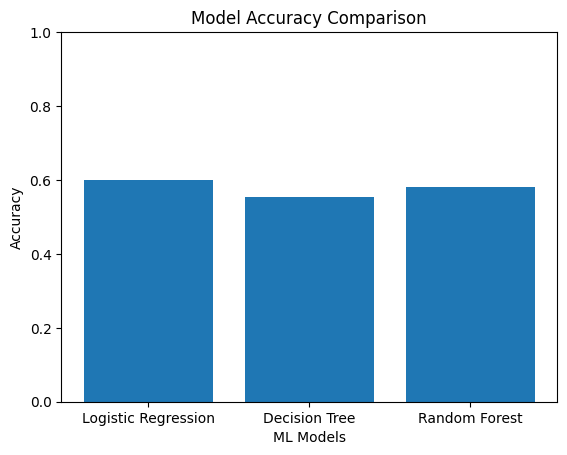

In [40]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracy = [0.601, 0.553, 0.582]

plt.bar(models, accuracy)

plt.xlabel("ML Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.ylim(0, 1)
plt.show()

In [41]:
from sklearn.linear_model import LogisticRegression

final_model = LogisticRegression(max_iter=1000)

final_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [42]:
new_project = pd.DataFrame({
    "Land_Area_Acres": [50],
    "Number_of_Owners": [10],
    "Number_of_Parcels": [15],
    "Legal_Cases": [2],
    "Ownership_Disputes": [1],
    "Documents_Missing": [3],
    "Objections_Received": [5],
    "Affected_Families": [20],
    "Government_Clearances": [4],
    "Planned_Duration_Days": [180],
    "Approval_Days": [60],
    "Project_Type_Housing": [0],
    "Project_Type_Industrial": [0],
    "Project_Type_Railway": [0],
    "Project_Type_Road": [1],
    "Location_Zone_Semi-Urban": [1],
    "Location_Zone_Urban": [0],
    "Land_Type_Commercial": [0],
    "Land_Type_Mixed": [0],
    "Land_Type_Residential": [1],
    "Rehabilitation_Required_Yes": [1],
    "Compensation_Dispute_Yes": [0],
    "Previous_Acquisition_Delay_Yes": [1]
})

In [43]:
prediction = final_model.predict(new_project)

prediction

array([1])

In [44]:
if prediction[0] == 1:
    print("Prediction: Project will be Delayed")
else:
    print("Prediction: Project will Not be Delayed")

Prediction: Project will be Delayed


In [45]:
probability = final_model.predict_proba(new_project)

print("Probability of No Delay:", probability[0][0])
print("Probability of Delay:", probability[0][1])

Probability of No Delay: 5.8475446707006995e-12
Probability of Delay: 0.9999999999941525


In [46]:
from sklearn.preprocessing import StandardScaler

# Numeric columns actually used in X
numeric_features = [
    "Land_Area_Acres",
    "Number_of_Owners",
    "Number_of_Parcels",
    "Legal_Cases",
    "Ownership_Disputes",
    "Documents_Missing",
    "Objections_Received",
    "Affected_Families",
    "Government_Clearances",
    "Planned_Duration_Days",
    "Approval_Days"
]

# Create a new scaler
new_scaler = StandardScaler()

# Fit scaler on the training data only
X_train[numeric_features] = new_scaler.fit_transform(
    X_train[numeric_features]
)

# Apply the same scaler to test data
X_test[numeric_features] = new_scaler.transform(
    X_test[numeric_features]
)

In [47]:
new_project[numeric_features] = new_scaler.transform(
    new_project[numeric_features]
)

In [48]:
new_project = new_project[X_train.columns]

In [49]:
prediction = final_model.predict(new_project)

if prediction[0] == 1:
    print("Prediction: Delayed")
else:
    print("Prediction: No Delay")

Prediction: Delayed


In [50]:
probability = final_model.predict_proba(new_project)

print("Probability of No Delay:", probability[0][0])
print("Probability of Delay:", probability[0][1])

Probability of No Delay: 6.9395600377220035e-12
Probability of Delay: 0.9999999999930604


### Predict Delay for a New Project with User Input

Now, let's create a function that allows you to input details for a new project and get a prediction from our `final_model` (Logistic Regression). This function will guide you through entering values for each feature, preprocess them, and then provide a prediction along with probabilities.

In [51]:
import pandas as pd

# Helper function for user input for binary features (Yes/No)
def get_binary_input(prompt):
    while True:
        response = input(prompt + " (Yes/No): ").strip().capitalize()
        if response == 'Yes':
            return 1
        elif response == 'No':
            return 0
        else:
            print("Invalid input. Please enter 'Yes' or 'No'.")

# Helper function for user input for numerical features
def get_numerical_input(prompt, type_func=float):
    while True:
        try:
            value = type_func(input(f"Enter value for {prompt}: "))
            return value
        except ValueError:
            print(f"Invalid input. Please enter a {type_func.__name__}.")

# Function to get all inputs and predict, now accepting model components as arguments
def predict_with_user_input(X_train_df, scaler_obj, model_obj):
    print("\nPlease provide details for the new project:")

    # Numerical features that were scaled
    numerical_features_for_input_df = [
        "Land_Area_Acres",
        "Number_of_Owners",
        "Number_of_Parcels",
        "Legal_Cases",
        "Ownership_Disputes",
        "Documents_Missing",
        "Objections_Received",
        "Affected_Families",
        "Government_Clearances",
        "Planned_Duration_Days",
        "Approval_Days"
    ]

    user_raw_data = {}

    # Get numerical inputs
    for feature in numerical_features_for_input_df:
        # 'Number_of_Owners', 'Number_of_Parcels', 'Legal_Cases', 'Ownership_Disputes',
        # 'Documents_Missing', 'Objections_Received', 'Affected_Families',
        # 'Government_Clearances', 'Planned_Duration_Days' are typically integers,
        # but float is fine if user enters integer.
        user_raw_data[feature] = get_numerical_input(feature)

    # Create an empty DataFrame with the exact columns as X_train
    # and initialize all values to 0.0
    user_project_df = pd.DataFrame(0.0, index=[0], columns=X_train_df.columns)

    # Populate numerical features into the new_project_row
    for feature in numerical_features_for_input_df:
        user_project_df.loc[0, feature] = user_raw_data[feature]

    # Handle categorical features and set corresponding dummy variables to 1.0
    # Project_Type
    project_type = input("Enter Project Type (Airport, Railway, Housing, Industrial, Road): ").strip().capitalize()
    if project_type != 'Airport': # 'Airport' is the base category (all dummy columns for Project_Type are 0)
        col_name = f"Project_Type_{project_type}"
        if col_name in user_project_df.columns:
            user_project_df.loc[0, col_name] = 1.0
        else:
            print(f"Warning: Unknown Project Type '{project_type}'. This type will be treated as 'Airport'.")

    # Location_Zone
    location_zone = input("Enter Location Zone (Urban, Semi-Urban, Rural): ").strip().capitalize()
    if location_zone != 'Rural': # 'Rural' is the base category
        col_name = f"Location_Zone_{location_zone}"
        if col_name in user_project_df.columns:
            user_project_df.loc[0, col_name] = 1.0
        else:
            print(f"Warning: Unknown Location Zone '{location_zone}'. This zone will be treated as 'Rural'.")

    # Land_Type
    land_type = input("Enter Land Type (Commercial, Residential, Agricultural, Mixed): ").strip().capitalize()
    if land_type != 'Agricultural': # 'Agricultural' is the base category
        col_name = f"Land_Type_{land_type}"
        if col_name in user_project_df.columns:
            user_project_df.loc[0, col_name] = 1.0
        else:
            print(f"Warning: Unknown Land Type '{land_type}'. This type will be treated as 'Agricultural'.")

    # Binary categorical features (Yes/No prompts directly map to _Yes columns)
    user_project_df.loc[0, "Rehabilitation_Required_Yes"] = float(get_binary_input("Rehabilitation Required"))
    user_project_df.loc[0, "Compensation_Dispute_Yes"] = float(get_binary_input("Compensation Dispute"))
    user_project_df.loc[0, "Previous_Acquisition_Delay_Yes"] = float(get_binary_input("Previous Acquisition Delay"))

    # Scale numerical features using the pre-fitted scaler
    user_project_df[numerical_features_for_input_df] = scaler_obj.transform(
        user_project_df[numerical_features_for_input_df]
    )

    # Ensure column order matches X_train before prediction
    user_project_df = user_project_df[X_train_df.columns]

    # Make prediction
    prediction = model_obj.predict(user_project_df)
    probability = model_obj.predict_proba(user_project_df)

    print("\n--- Prediction Results ---")
    if prediction[0] == 1:
        print("Prediction: Project will be Delayed")
    else:
        print("Prediction: Project will Not be Delayed")

    print(f"Probability of No Delay: {probability[0][0]:.4f}")
    print(f"Probability of Delay: {probability[0][1]:.4f}")

    return prediction[0], probability[0]

In [52]:
# Call the function to get user input and make a prediction
predicted_delay, probabilities = predict_with_user_input(X_train, new_scaler, final_model)


Please provide details for the new project:
Enter value for Land_Area_Acres: 1500
Enter value for Number_of_Owners: 2
Enter value for Number_of_Parcels: 1
Enter value for Legal_Cases: 1
Enter value for Ownership_Disputes: 0
Enter value for Documents_Missing: 1
Enter value for Objections_Received: 0
Enter value for Affected_Families: 0
Enter value for Government_Clearances: 1
Enter value for Planned_Duration_Days: 100
Enter value for Approval_Days: 50
Enter Project Type (Airport, Railway, Housing, Industrial, Road): housing
Enter Location Zone (Urban, Semi-Urban, Rural): urban
Enter Land Type (Commercial, Residential, Agricultural, Mixed): residential
Rehabilitation Required (Yes/No): no
Compensation Dispute (Yes/No): no
Previous Acquisition Delay (Yes/No): no

--- Prediction Results ---
Prediction: Project will Not be Delayed
Probability of No Delay: 1.0000
Probability of Delay: 0.0000
